In [ ]:
# ======================================================================================
#  Imports
# ======================================================================================

import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import copy
import seaborn as sns
import pandas as pd

from bmg_Tony import bmg, bmg_fast
from MISC_Functions import MultiLayerdBICCherry
from bmg_fun import convert_to_nx
from insert_hybrid import insertHybrid
from BICcherryRestrict import BICcherryRestrict


# ======================================================================================
#  Konfiguration
# ======================================================================================

species_range: tuple = tuple(range(2, 11))   # Anzahl Spezies im Genbaum
trees_per_n: int = 200                       # Genbäume pro Speziesanzahl
n_runs: int = 25                             # Runs (Hybrid-Sequenzen) pro Baum
max_leaves: int = 25                         # Obergrenze Blätter (Rechenaufwand)
max_hybrids: int = 100                       # Sicherheitsgrenze pro Run
MODE = "weak"
multilayered = False


# ======================================================================================
#  Baumgenerierung
# ======================================================================================

def generateGeneTree(seed:int = None, nSpecies:int = 2, max_leaves: int = 40):
    # Generiert einen Genbaum, der maximal max_leaves Blätter hat und nSpecies Spezies.
    if seed:
        # Setze den Seed für Pythons Standard-Zufallsfunktionen
        random.seed(seed)
        # Setze den Seed für NumPys Zufallsfunktionen (wichtig für AsymmeTree)
        np.random.seed(seed)


    while True:

        # species tree
        speciesTree = te.species_tree_n_age(
            age = 1.0,
            n = nSpecies
            #, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
        )
        # gene tree
        T = te.dated_gene_tree(
            speciesTree, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
        )
        # prune all loss branches and the planted root
        geneTree = te.prune_losses(T)

        geneTree = convert_to_nx(geneTree)

        nLeaves = sum(1 for node in geneTree.nodes() if geneTree.out_degree(node) == 0)

        if nLeaves < max_leaves and nLeaves > 2:  #wenn es nur zwei Blätter (oder nSpezies?????) gibt, so lassen sich keine Hybriden einfügen
            break

    return geneTree, nLeaves

# ======================================================================================
#  Check BCBMG
# ======================================================================================
def check_BCBMG(Network :nx.DiGraph, mode :str = 'weak', multilayered :bool = False) ->bool:
    BMG = bmg_fast(Network,mode = mode)

    if multilayered:
        BC = MultiLayerdBICCherry(BMG)
    if not multilayered:
        BC = BICcherryRestrict(BMG)

    BCBMG = bmg_fast(BC, mode = mode)

    return nx.utils.graphs_equal(BMG,BCBMG)

# ======================================================================================
#  Ein Run: Hybride einfügen bis der BCEA scheitert
# ======================================================================================
def insert_hybrid_till_break(Tree :nx.DiGraph, max_hybrids :int = 50, mode :str = 'weak', multilayered :bool = False) ->int:

    insertedHybrids = 0

    Network = copy.deepcopy(Tree)

    while check_BCBMG(Network, mode = mode, multilayered = multilayered) and insertedHybrids < max_hybrids:

        Network = insertHybrid(Network)
        insertedHybrids += 1

    return insertedHybrids                           # Was tun, wenn Obergrenze erreicht wird?

# ======================================================================================
# 1. Baum generieren mit x leaves
# 2. y mal Hybriden einfügen und schauen nach wie vielen er bricht
# 2b Zahl speichern in Array mit Anzahl nodes/leaves ???????? vs. Anzahl Spezies
# 3. Plot  
# ======================================================================================

matrix = np.zeros((len(species_range), max_leaves))

for row_idx, nSpecies in enumerate(species_range):
    for t in range(trees_per_n):
        insertedHybrids = 0

        for run in range(n_runs):
            
            Tree, nLeaves = generateGeneTree(nSpecies=nSpecies, max_leaves=max_leaves)
            insertedHybrids += insert_hybrid_till_break(Tree, max_hybrids=max_hybrids, mode = MODE, multilayered=multilayered)

        matrix[row_idx,nLeaves] = insertedHybrids / n_runs

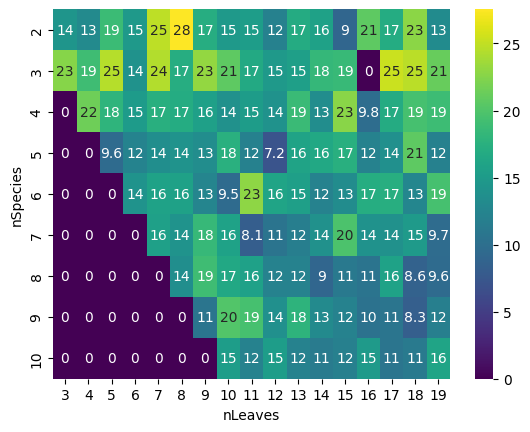

In [2]:
# ======================================================================================
#  Plot
# ======================================================================================

# Matrix-Slicing: Spalten 0,1 und 2 uninteressant da nur Bäume mit mindestens 3 leaves Sinn machen
matrix_sliced = matrix[:, 3:]
x_labels = range(3, matrix.shape[1])


sns.heatmap(matrix_sliced, 
            annot=True, 
            cmap="viridis", 
            yticklabels=list(species_range), 
            xticklabels=list(x_labels))
plt.xlabel("nLeaves")
plt.ylabel("nSpecies")
plt.show()